# BÀI TẬP: EDA HOÀN CHỈNH — TITANIC
## Data Profiling → Descriptive Statistics → Define the Question
**Nguồn:** kaggle.com/c/titanic (891 dòng)

```
PHẦN A — DATA PROFILING       : dữ liệu sạch chưa, có gì
PHẦN B — DESCRIPTIVE STATS    : từng biến trông như thế nào
PHẦN C — DEFINE THE QUESTION  : đặt câu hỏi kinh doanh, trả lời bằng code, rút insight
```

## Setup

In [2]:
!pip install matplotlib
!pip install seaborn
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [6]:
# TODO
print("Số dòng: ", df.shape[0], "| Số cột: ",df.shape[1])
print()
df.info()
print()
print("Danh sách column names: ", ', '.join(df.columns.tolist()))


Số dòng:  891 | Số cột:  15

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB

Danh sách column names:  survived, pclass, sex, age, sibsp, parch, fare, embarked, class, who,

## A.2. Missing values & Duplicate data

In [4]:
# TODO
missing = df.isnull().sum() 
print("Số dữ liệu bị mất của từng cột:")
print(missing[missing>0] if missing.sum()>0 else "Không có dữ liệu nào trống")
print()
print("Số dữ liệu bị trùng lắp:")
print(df.duplicated().sum())
df

Số dữ liệu bị mất của từng cột:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

Số dữ liệu bị trùng lắp:
107


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


## A.3. Invalid values

In [ ]:
# TODO
print("survived is null: ", df['survived'].isnull().sum())
print("survived is out [0,1]: ",((df['survived']<0) & (df['survived']>1)).sum())
print("pclass is null: ", df['pclass'].isnull().sum())
print("sex khac male hoac female: ", ((df['sex']!='male') & (df['sex']!='female')).sum())
print("age is null: ", df['age'].isnull().sum())
print("sibsp is null: ", df['sibsp'].isnull().sum())
print("sibsp is out [0,1]: ",((df['sibsp']<0) & (df['sibsp']>1)).sum())
print("parch is null: ", df['parch'].isnull().sum())
print("fare is null: ", df['fare'].isnull().sum())
print("embarked is null: ", df['embarked'].isnull().sum())
print("class is null: ", df['class'].isnull().sum())
print("who is null: ", df['who'].isnull().sum())
print("who khac male,female hoac child: ", ((df['who']!='man') & (df['who']!='woman') & (df['who'] != 'child')).sum())
print("adult_male is null: ", df['adult_male'].isnull().sum())
print("deck is null: ", df['deck'].isnull().sum())
print("embark_town is null: ", df['embark_town'].isnull().sum())
print("alive is null: ", df['alive'].isnull().sum())
print("alone is null: ", df['alone'].isnull().sum())

survived is null:  0
survived is out [0,1]:  0
pclass is null:  0
sex khac male hoac female:  0
age is null:  177
sibsp is null:  0
sibsp is out [0,1]:  0
parch is null:  0
fare is null:  0
embarked is null:  2
class is null:  0
who is null:  0
who khac male hoac female:  0
adult_male is null:  0
deck is null:  688
embark_town is null:  2
alive is null:  0
alone is null:  0


## A.4. Create a new column
Tạo cột `family_size` = sibsp + parch + 1.

In [10]:
# TODO
df['family_size'] = df['sibsp'] + df['parch'] + 1
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,fare_group,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,"(-0.001, 7.91]",2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,"(31.0, 512.329]",2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,"(7.91, 14.454]",1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,"(31.0, 512.329]",2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,"(7.91, 14.454]",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,"(7.91, 14.454]",1
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,"(14.454, 31.0]",1
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,"(14.454, 31.0]",4
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,"(14.454, 31.0]",1


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [3]:
# TODO
# TODO
for col in ['age', 'fare']:
    mean_, median_, mode_ = df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f"{col}: Mean={mean_: .2f}, Median={median_: .2f}, Mode={mode_: .2f}")

age: Mean= 29.70, Median= 28.00, Mode= 24.00
fare: Mean= 32.20, Median= 14.45, Mode= 8.05


## Group 2 — Dispersion

In [4]:
# TODO
for col in ['age', 'fare']:
    s = df[col]
    range_ = s.max() - s.min()
    var_ = s.var()
    std_ = s.std()
    q1,q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    cv = std_/s.mean()
    print(f"---- {col} ----")
    print(f"Range={range_: .2f}, Var={var_: .2f}, STD={std_: .2f}, IQR={iqr: .2f}, CV={cv: .2f}")

---- age ----
Range= 79.58, Var= 211.02, STD= 14.53, IQR= 17.88, CV= 0.49
---- fare ----
Range= 512.33, Var= 2469.44, STD= 49.69, IQR= 23.09, CV= 1.54


## Group 3 — Location and Shape

---- age ----
PS25= 20.12, PS50= 28.00, PS75= 38.00
Skewness= 0.39, Kurtosis= 0.17


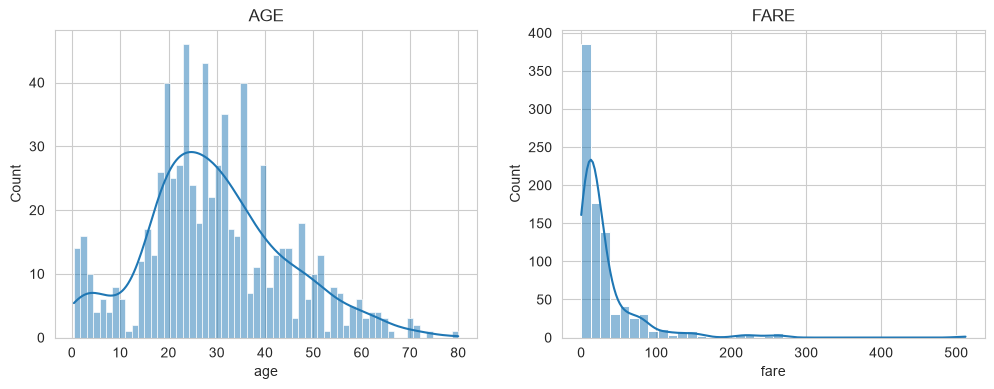

Nhận xét: Fare lệch phải rất mạnh và có kurtosis cao hơn hẳn Age -> nhiều outlier lợi nhuận cực đoan hơn
---- fare ----
PS25= 7.91, PS50= 14.45, PS75= 31.00
Skewness= 4.78, Kurtosis= 33.20


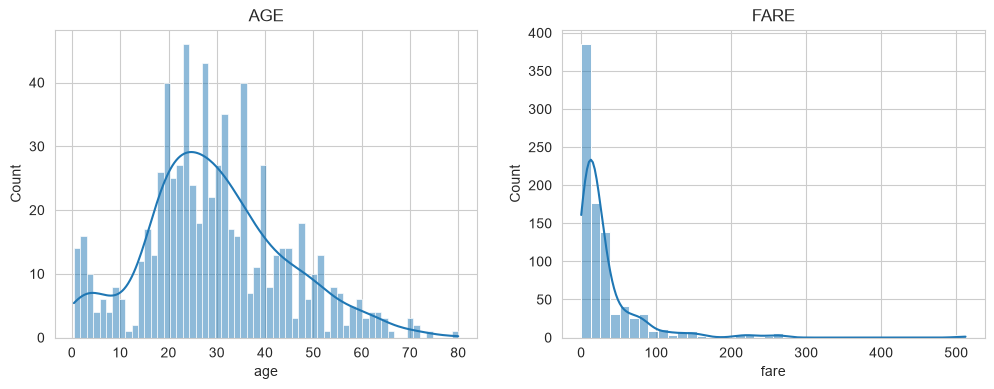

Nhận xét: Fare lệch phải rất mạnh và có kurtosis cao hơn hẳn Age -> nhiều outlier lợi nhuận cực đoan hơn


In [5]:
# TODO
for col in ['age', 'fare']:
    s = df[col].dropna()
    skew_,kurt_ = stats.skew(s) , stats.kurtosis(s)
    print(f"---- {col} ----")
    print(f"PS25={s.quantile(0.25): .2f}, PS50={s.quantile(0.5): .2f}, PS75={s.quantile(0.75): .2f}")
    print(f"Skewness={skew_: .2f}, Kurtosis={kurt_: .2f}");

    fig,axes = plt.subplots(1,2,figsize=(12,4))
    sns.histplot(df['age'], bins=60, kde=True,ax=axes[0]); axes[0].set_title('AGE')
    sns.histplot(df['fare'], bins=40, kde=True, ax=axes[1]); axes[1].set_title('FARE')
    plt.tight_layout; plt.show()


    print("Nhận xét: Fare lệch phải rất mạnh và có kurtosis cao hơn hẳn Age -> nhiều outlier lợi nhuận cực đoan hơn")

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Hạng vé nào có tỷ lệ sống sót cao nhất, chênh lệch bao nhiêu so với hạng thấp nhất?

In [66]:
# TODO
#Hang ve co ti le song sot cao nhat
survival_rate = df.groupby('class')['survived'].mean() * 100
top_survival_rate = survival_rate.max()
top_survival_rank = survival_rate.idxmax()
bottom_survival_rate = survival_rate.min()
bottom_survival_rank = survival_rate.idxmin()

print('Hạng vé có tỷ lệ sống sót cao nhất: ',top_survival_rank,round(top_survival_rate,2),"%")
print('Hạng có tỷ lệ sống sót thấp nhất: ',bottom_survival_rank,round(bottom_survival_rate,2),"%")
survival_rate_gap_of_class = round(top_survival_rate-bottom_survival_rate,2)
print('Chênh lệch: ',survival_rate_gap_of_class,"%")



Hạng vé có tỷ lệ sống sót cao nhất:  First 62.96 %
Hạng có tỷ lệ sống sót thấp nhất:  Third 24.24 %
Chênh lệch:  38.73 %


## Câu hỏi 2: Giới tính hay hạng vé ảnh hưởng đến sống sót mạnh hơn?

In [68]:
# TODO
survival_rate_of_sex = df.groupby('sex')['survived'].mean() * 100
top_survival_rate_of_sex = survival_rate_of_sex.max()
sex_high_survival_rate = survival_rate_of_sex.idxmax()
bottom_survival_rate_of_sex = survival_rate_of_sex.min()
sex_low_survival_rate = survival_rate_of_sex.idxmin()

print("Giới tính có tỷ lệ sống sót cao nhất: ",sex_high_survival_rate,round(top_survival_rate_of_sex,2),"%")
print("Giới tính có tỷ lệ sống sót thấp nhất: ",sex_low_survival_rate,round(bottom_survival_rate_of_sex,2),"%")
survival_rate_gap_of_sex = round(top_survival_rate_of_sex-bottom_survival_rate_of_sex,2)
print("Chênh lệch: ",survival_rate_gap_of_sex,"%")
print()
print("Dựa vào sự trên lệch của câu 1 và câu 2 ta thấy:")
print("Sự chênh lệch của giới tính ",survival_rate_gap_of_sex,"% ","> sự chênh lệch của hạng vé ",survival_rate_gap_of_class," %")
print("Do đó giới tính ảnh hưởng tới tỉ lệ sống sót mạnh hơn hạng vé")

Giới tính có tỷ lệ sống sót cao nhất:  female 74.2 %
Giới tính có tỷ lệ sống sót thấp nhất:  male 18.89 %
Chênh lệch:  55.31 %

Dựa vào sự trên lệch của câu 1 và câu 2 ta thấy:
Sự chênh lệch của giới tính  55.31 %  > sự chênh lệch của hạng vé  38.73  %
Do đó giới tính ảnh hưởng tới tỉ lệ sống sót mạnh hơn hạng vé


## Câu hỏi 3: Vé đắt hơn có thực sự sống sót cao hơn không?

In [ ]:
# TODO
df['fare_group'] = pd.qcut(df['fare'], 4)
df.groupby('fare_group')['survived'].mean() * 100
survival_by_fare = df.groupby('fare_group')['survived'].mean() * 100

difference = survival_by_fare.iloc[-1] - survival_by_fare.iloc[0]

print(survival_by_fare)
print("Chênh lệch:", round(difference, 2), "%")
print()
print("Dựa vào các phân khúc vé ở trên ta thấy được giá vé đắt hơn sẽ có tỷ lẹ sống sót cao hơn ")

fare_group
(-0.001, 7.91]     19.730942
(7.91, 14.454]     30.357143
(14.454, 31.0]     45.495495
(31.0, 512.329]    58.108108
Name: survived, dtype: float64
Chênh lệch: 38.38 %


## Câu hỏi 4: Gia đình đông người có ảnh hưởng đến khả năng sống sót không?

In [ ]:
# TODO
survival_by_family = df.groupby('family_size')['survived'].mean() * 100

print(survival_by_family)
print()
print('Ta thấy tỉ lệ sống sót của gia đình đông người thấp hơn gia đình ít, người gia đình có family_size 4 có tỷ lệ sống sót cao nhất')

family_size
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: survived, dtype: float64
Ta thấy tỉ lệ sống sót của gia đình đông người thấp hơn gia đình ít, người gia đình có family_size 4 có tỷ lệ sống sót cao nhất


## Câu hỏi 5: Cảng lên tàu (embark_town) nào có tỷ lệ sống sót cao nhất?

In [17]:
# TODO
survival_by_town = (df.groupby('embark_town')['survived'].mean() * 100).round(2)

top_town = survival_by_town.idxmax()
top_rate = survival_by_town.max()

print("Cảng có tỷ lệ sống sót cao nhất: ",top_town)
print("Tỷ lệ",top_rate,"%")

Cảng có tỷ lệ sống sót cao nhất:  Cherbourg
Tỷ lệ 55.36 %


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Titanic.

Về phần dữ liệu trong bảng vẫn còn thiếu nhiều dữ liệu, Fare lệch phải rất mạnh và có kurtosis cao hơn hẳn Age -> nhiều outlier lợi nhuận cực đoan hơn. Khả năng sống sót ở nữ cao hơn ở nam. Gia đình từ 2 người -  4 người có tỷ lệ sống sót cao hơn gia đình cao hơn. Giá vé đắt, hạng vé cao cũng có cơ hội sóng sót cao hơn. Cảng có tỷ lệ sống sót cao nhất là Cherbourg. 